## Analyse du data


In [1]:
# load data
import pandas as pd

df = pd.read_csv("../data/raw/jobs_data.csv")
df.head(10)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
5,5,Data Scientist,$137K-$171K (Glassdoor est.),About Us:\n\nHeadquartered in beautiful Santa ...,4.2,HG Insights\n4.2,"Santa Barbara, CA","Santa Barbara, CA",51 to 200 employees,2010,Company - Private,Computer Hardware & Software,Information Technology,Unknown / Non-Applicable,-1
6,6,Data Scientist / Machine Learning Expert,$137K-$171K (Glassdoor est.),Posting Title\nData Scientist / Machine Learni...,3.9,Novartis\n3.9,"Cambridge, MA","Basel, Switzerland",10000+ employees,1996,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$10+ billion (USD),-1
7,7,Data Scientist,$137K-$171K (Glassdoor est.),Introduction\n\nHave you always wanted to run ...,3.5,iRobot\n3.5,"Bedford, MA","Bedford, MA",1001 to 5000 employees,1990,Company - Public,Consumer Electronics & Appliances Stores,Retail,$1 to $2 billion (USD),-1
8,8,Staff Data Scientist - Analytics,$137K-$171K (Glassdoor est.),Intuit is seeking a Staff Data Scientist to co...,4.4,Intuit - Data\n4.4,"San Diego, CA","Mountain View, CA",5001 to 10000 employees,1983,Company - Public,Computer Hardware & Software,Information Technology,$2 to $5 billion (USD),"Square, PayPal, H&R Block"
9,9,Data Scientist,$137K-$171K (Glassdoor est.),Ready to write the best chapter of your career...,3.6,XSELL Technologies\n3.6,"Chicago, IL","Chicago, IL",51 to 200 employees,2014,Company - Private,Enterprise Software & Network Solutions,Information Technology,Unknown / Non-Applicable,-1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    str    
 2   Salary Estimate    672 non-null    str    
 3   Job Description    672 non-null    str    
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    str    
 6   Location           672 non-null    str    
 7   Headquarters       672 non-null    str    
 8   Size               672 non-null    str    
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    str    
 11  Industry           672 non-null    str    
 12  Sector             672 non-null    str    
 13  Revenue            672 non-null    str    
 14  Competitors        672 non-null    str    
dtypes: float64(1), int64(2), str(12)
memory usage: 2.4 MB


In [3]:
df.describe()

,index,Rating,Founded
count,672.000000,672.000000,672.000000
mean,335.500000,3.518601,1635.529762
std,194.133974,1.410329,756.746640
min,0.000000,-1.000000,-1.000000
25%,167.750000,3.300000,1917.750000
50%,335.500000,3.800000,1995.000000
75%,503.250000,4.300000,2009.000000
max,671.000000,5.000000,2019.000000


In [4]:
df.columns.to_list()

['index',
 'Job Title',
 'Salary Estimate',
 'Job Description',
 'Rating',
 'Company Name',
 'Location',
 'Headquarters',
 'Size',
 'Founded',
 'Type of ownership',
 'Industry',
 'Sector',
 'Revenue',
 'Competitors']

In [5]:
df.shape

(672, 15)

In [6]:
# null values
print(df.isnull().sum())

index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64


In [7]:
# verifier les doublons
print("Doublons:", df.duplicated().sum())


Doublons: 0


In [8]:
# type 
print(df.dtypes)

index                  int64
Job Title                str
Salary Estimate          str
Job Description          str
Rating               float64
Company Name             str
Location                 str
Headquarters             str
Size                     str
Founded                int64
Type of ownership        str
Industry                 str
Sector                   str
Revenue                  str
Competitors              str
dtype: object


## Creation du salary_clean

In [9]:
df["Salary Estimate"].value_counts().head()

Salary Estimate
$75K-$131K (Glassdoor est.)     32
$79K-$131K (Glassdoor est.)     32
$99K-$132K (Glassdoor est.)     32
$137K-$171K (Glassdoor est.)    30
$90K-$109K (Glassdoor est.)     30
Name: count, dtype: int64

In [10]:
from preprocessing import clean_salary

df["salary_clean"] = df["Salary Estimate"].apply(clean_salary)

print(df[["Salary Estimate", "salary_clean"]].head())


                Salary Estimate  salary_clean
0  $137K-$171K (Glassdoor est.)      154000.0
1  $137K-$171K (Glassdoor est.)      154000.0
2  $137K-$171K (Glassdoor est.)      154000.0
3  $137K-$171K (Glassdoor est.)      154000.0
4  $137K-$171K (Glassdoor est.)      154000.0


In [11]:
print("Null values:", df["salary_clean"].isnull().sum())


Null values: 0


In [12]:
print(df["salary_clean"].describe())


count       672.000000
mean     123663.690476
std       39580.267895
min       43500.000000
25%      103000.000000
50%      114000.000000
75%      136500.000000
max      271500.000000
Name: salary_clean, dtype: float64


## Outliers

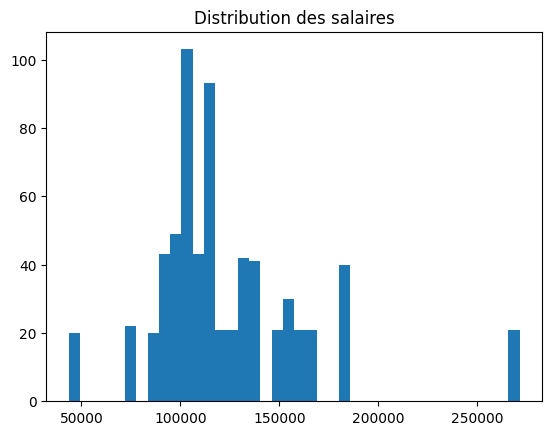

In [13]:
import matplotlib.pyplot as plt

plt.hist(df["salary_clean"].dropna(), bins=40)
plt.title("Distribution des salaires")
plt.show()


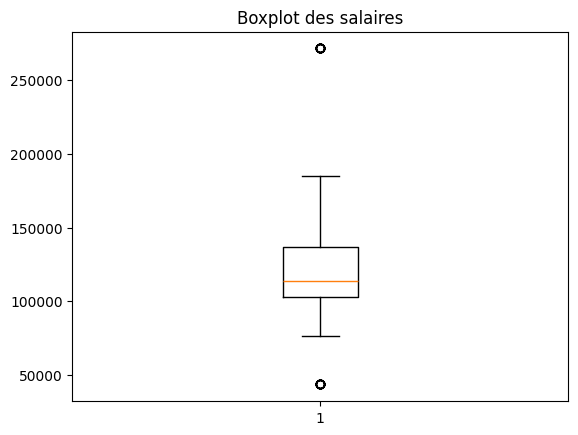

In [14]:
# verrification les outliers
plt.boxplot(df["salary_clean"].dropna())
plt.title("Boxplot des salaires")
plt.show()


In [15]:
# supprimer outliers
df = df[(df["salary_clean"] >= 5000) &
        (df["salary_clean"] <= 200000)
]

## Company Name

In [17]:
# supprimer la note qui est collee au nom de l'entreprise

df['company_name'] = df['Company Name'].apply(lambda x: x.split('\n')[0])

df[['Company Name', 'company_name']].head()

,Company Name,company_name
0,Healthfirst\n3.1,Healthfirst
1,ManTech\n4.2,ManTech
2,Analysis Group\n3.8,Analysis Group
3,INFICON\n3.5,INFICON
4,Affinity Solutions\n2.9,Affinity Solutions


## Location

In [18]:
# extraction de location

df['location'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())

print(df['location'].value_counts().head())

location
CA    164
VA     87
MA     60
NY     49
MD     39
Name: count, dtype: int64


## Size


In [19]:
df["Size"].value_counts()

Size
51 to 200 employees        131
1001 to 5000 employees     101
1 to 50 employees           84
201 to 500 employees        82
10000+ employees            78
501 to 1000 employees       75
5001 to 10000 employees     59
-1                          26
Unknown                     15
Name: count, dtype: int64

In [20]:
# regrouper Size en categories
from preprocessing import categorize_size

df["size_category"] = df["Size"].apply(categorize_size)
df[["Size", "size_category"]].head()

,Size,size_category
0,1001 to 5000 employees,Small
1,5001 to 10000 employees,Enterprise
2,1001 to 5000 employees,Small
3,501 to 1000 employees,Medium
4,51 to 200 employees,Small


## Founded

In [21]:
# calcule de l'age de l'entreprise

df['founded'] = df.Founded.apply(lambda x: x if x < 1 else 2026 - x)
df[['Founded', 'founded']].head()

,Founded,founded
0,1993,33
1,1968,58
2,1981,45
3,2000,26
4,1998,28


## Type of ownership

In [22]:
df["Type of ownership"].value_counts()

Type of ownership
Company - Private                 390
Company - Public                  144
Nonprofit Organization             33
Subsidiary or Business Segment     28
-1                                 26
Government                          9
Other Organization                  5
Private Practice / Firm             4
Unknown                             4
College / University                3
Self-employed                       2
Contract                            2
Hospital                            1
Name: count, dtype: int64

In [23]:
from preprocessing import categorize_ownership

df["ownership_category"] = df["Type of ownership"].apply(categorize_ownership)

df[["Type of ownership", "ownership_category"]].head()

,Type of ownership,ownership_category
0,Nonprofit Organization,Nonprofit
1,Company - Public,Public
2,Private Practice / Firm,Private
3,Company - Public,Public
4,Company - Private,Private


## Job Titile

In [24]:
# job title

from preprocessing import job_title, extract_seniority, extract_role

df["job_title"] = df["Job Title"].apply(job_title)

df["Seniority"] = df["job_title"].apply(extract_seniority)
df["role"] = df["job_title"].apply(extract_role)

df[['Job Title', 'role']].head()


,Job Title,role
0,Sr Data Scientist,Data Scientist
1,Data Scientist,Data Scientist
2,Data Scientist,Data Scientist
3,Data Scientist,Data Scientist
4,Data Scientist,Data Scientist


## Secteur & Industry

In [25]:
import numpy as np

df["Industry"] = df["Industry"].replace("-1", np.nan)
df["Sector"] = df["Sector"].replace("-1", np.nan)

## Revenue


In [26]:
df["Revenue"].value_counts()

Revenue
Unknown / Non-Applicable            205
$100 to $500 million (USD)           93
$10+ billion (USD)                   61
$2 to $5 billion (USD)               43
$10 to $25 million (USD)             40
$1 to $2 billion (USD)               35
$25 to $50 million (USD)             35
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   26
$500 million to $1 billion (USD)     17
$5 to $10 million (USD)              13
Less than $1 million (USD)           13
$5 to $10 billion (USD)               8
Name: count, dtype: int64

In [27]:
# ransformer Revenue en categorie

from preprocessing import categorize_revenue

df["revenue_category"] = df["Revenue"].apply(categorize_revenue)

df[["Revenue", "revenue_category"]].head()


,Revenue,revenue_category
0,Unknown / Non-Applicable,Unknown
1,$1 to $2 billion (USD),Enterprise
2,$100 to $500 million (USD),Unknown
3,$100 to $500 million (USD),Unknown
4,Unknown / Non-Applicable,Unknown


## Competitors

In [28]:
df["Competitors"].value_counts()

Competitors
-1                                                             486
Roche, GlaxoSmithKline, Novartis                                 9
Leidos, CACI International, Booz Allen Hamilton                  6
Los Alamos National Laboratory, Battelle, SRI International      4
Commerce Signals, Cardlytics, Yodlee                             3
                                                              ... 
United Natural Foods, US Foods, DPI Specialty Foods              1
LivePerson, Salesforce, SAP                                      1
Zurich Insurance, AXA XL, Allianz                                1
CSC, ManTech, SAIC                                               1
Genomic Health, Myriad Genetics, The Broad Institute             1
Name: count, Length: 106, dtype: int64

In [29]:
# remplacer -1 par "NaN"
import numpy as np
df["competitors"] = df["Competitors"].replace("-1", np.nan)
df[["Competitors", "competitors"]].head()

,Competitors,competitors
0,"EmblemHealth, UnitedHealth Group, Aetna","EmblemHealth, UnitedHealth Group, Aetna"
1,-1,NaN
2,-1,NaN
3,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...","MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,"Commerce Signals, Cardlytics, Yodlee","Commerce Signals, Cardlytics, Yodlee"


## Embeddings

In [30]:
# embeddings du Job Description

from embedding import load_embedding_model, generate_embedding

model = load_embedding_model()

job_description = df["Job Description"].tolist()
embeddings = generate_embedding(model, job_description)
# df["Job Description"] = embeddings.tolist()


/home/nouhayla/Desktop/simplon_projects/HR-Pulse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 494.21it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Sauvgarder clean data

In [31]:
#  sauvgarder clean data

df_cleaned = df[['role',
 'salary_clean',
 'Job Description',
 'Rating',
 'company_name',
 'location',
 'Headquarters',
 'size_category',
 'founded',
 'ownership_category',
 'Industry',
 'Sector',
 'revenue_category',
 'competitors']]


df_cleaned.to_csv('../data/processed/jobs_data_cleaned.csv', index=False)


In [32]:
df_cleaned.dtypes

role                      str
salary_clean          float64
Job Description           str
Rating                float64
company_name              str
location                  str
Headquarters              str
size_category             str
founded                 int64
ownership_category        str
Industry                  str
Sector                    str
revenue_category          str
competitors               str
dtype: object

## Features qui impactent target

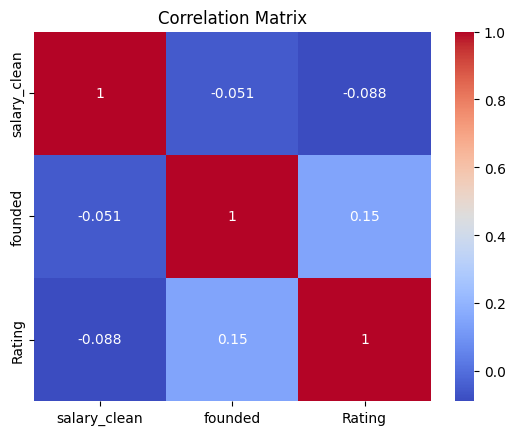

In [33]:
# matrice de correlation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

col_numeric = [
 'salary_clean',
 'founded',
 'Rating' 
 ]


corr = df_cleaned [col_numeric].corr()

plt.figure()
sns.heatmap(corr,annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



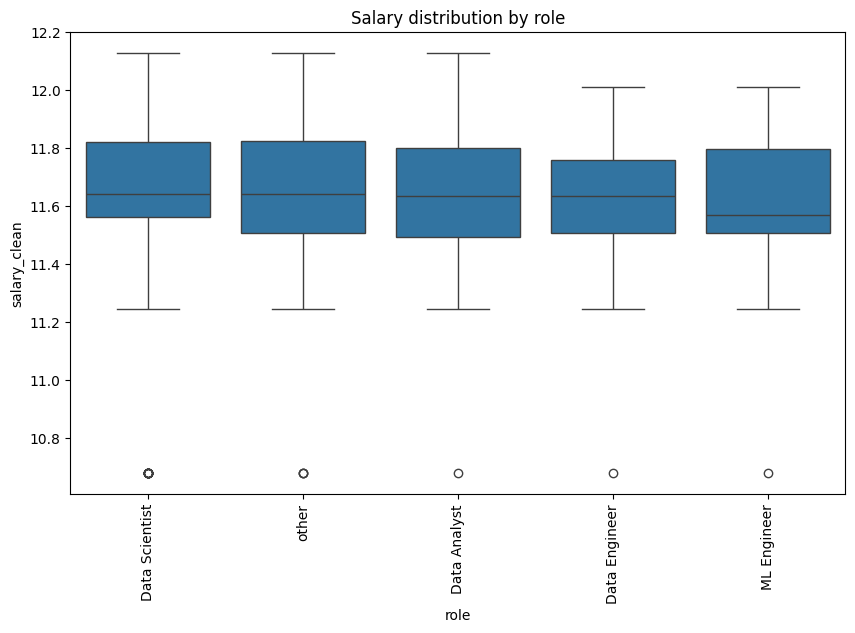

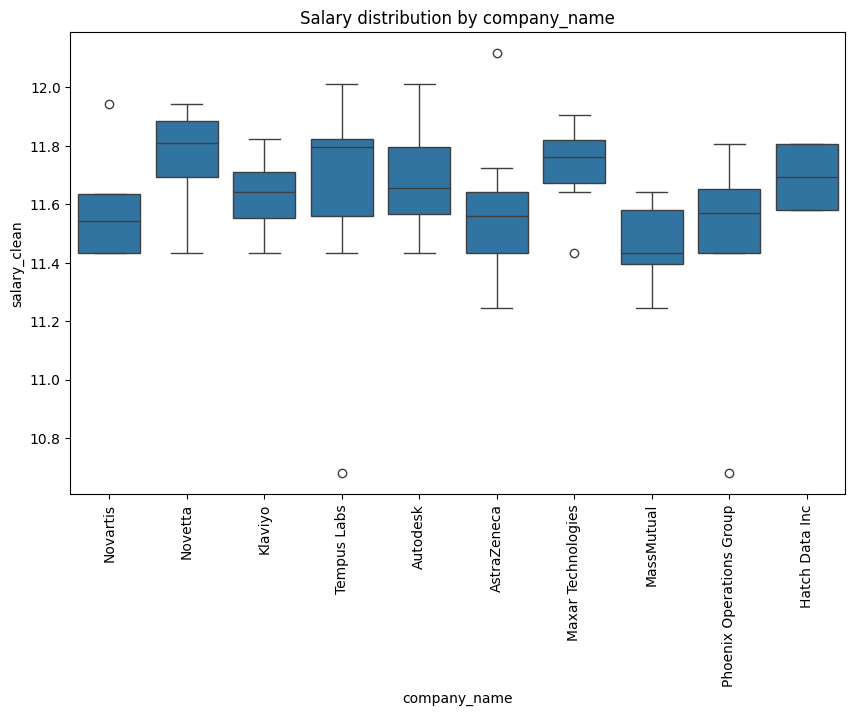

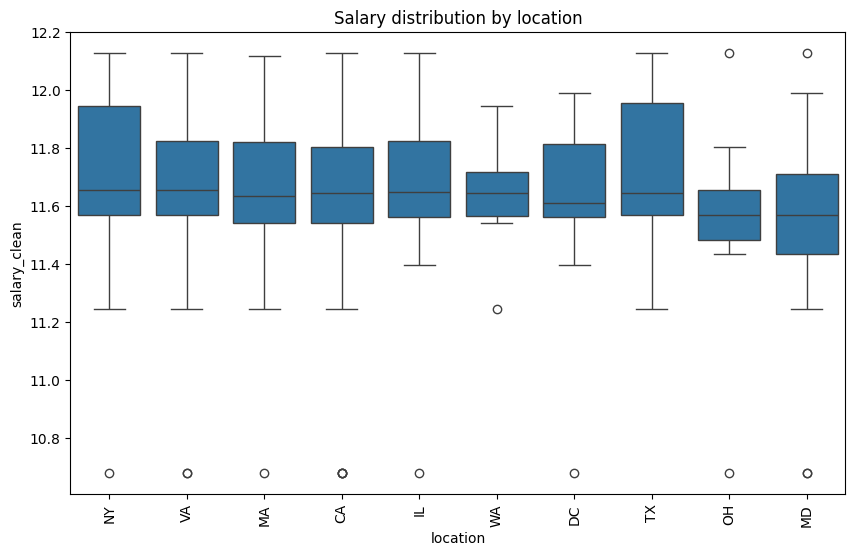

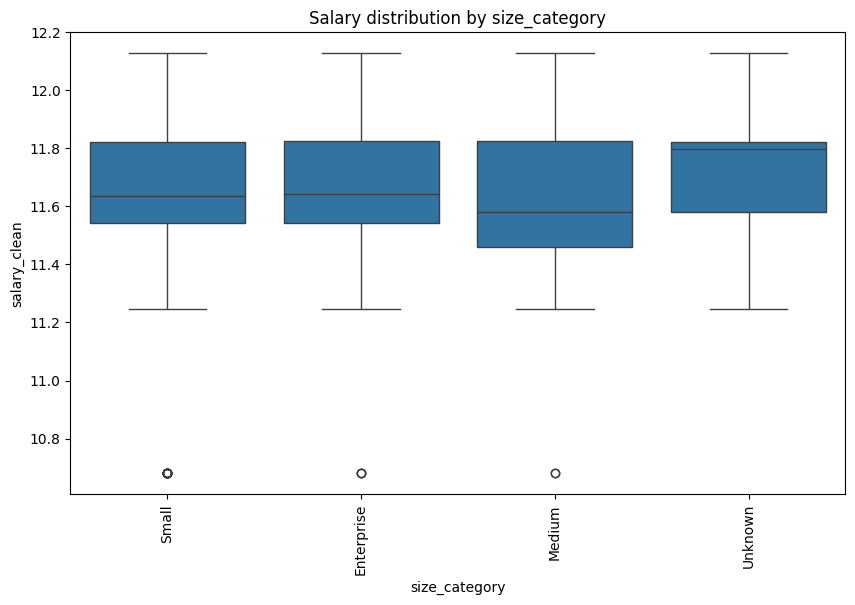

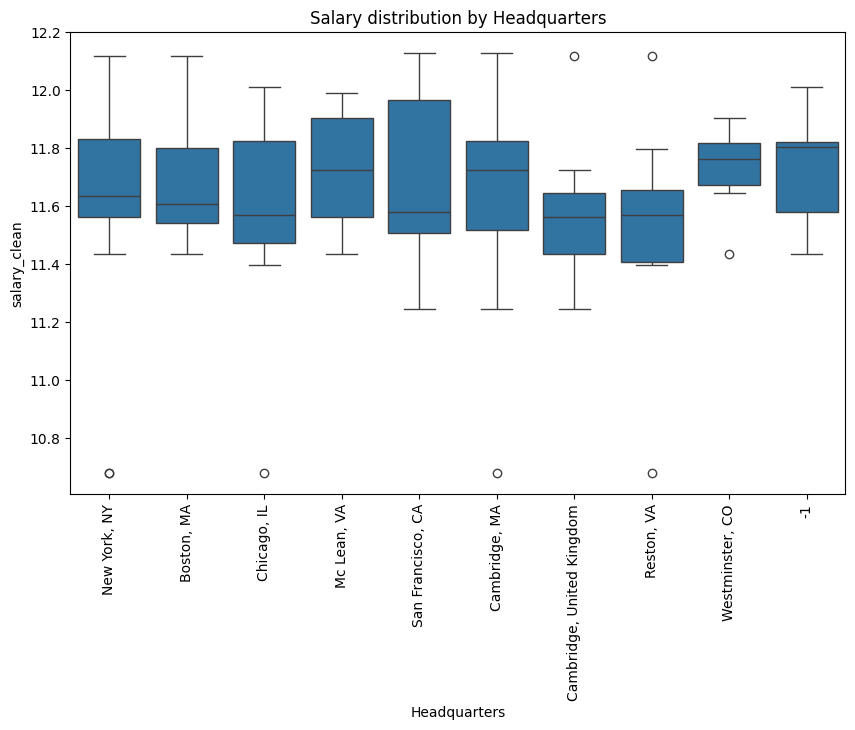

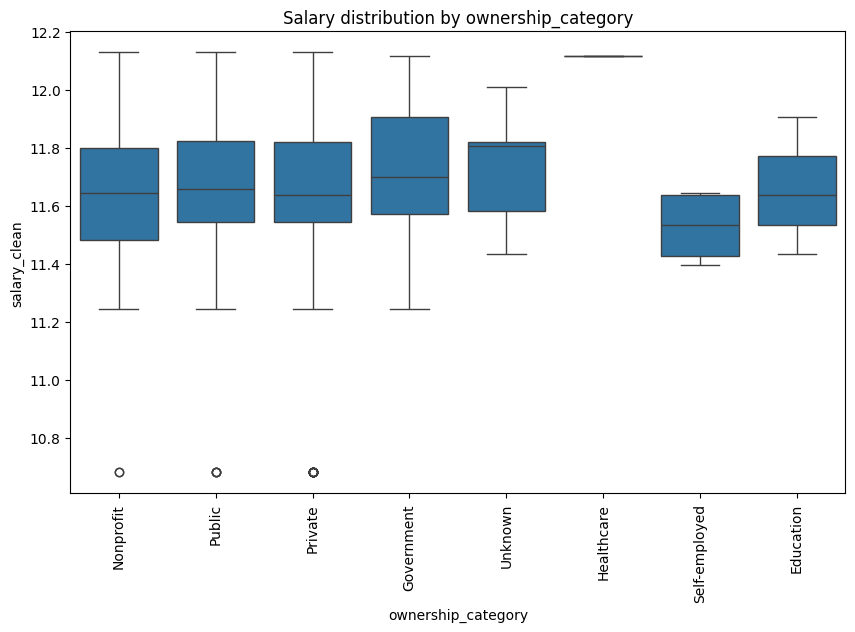

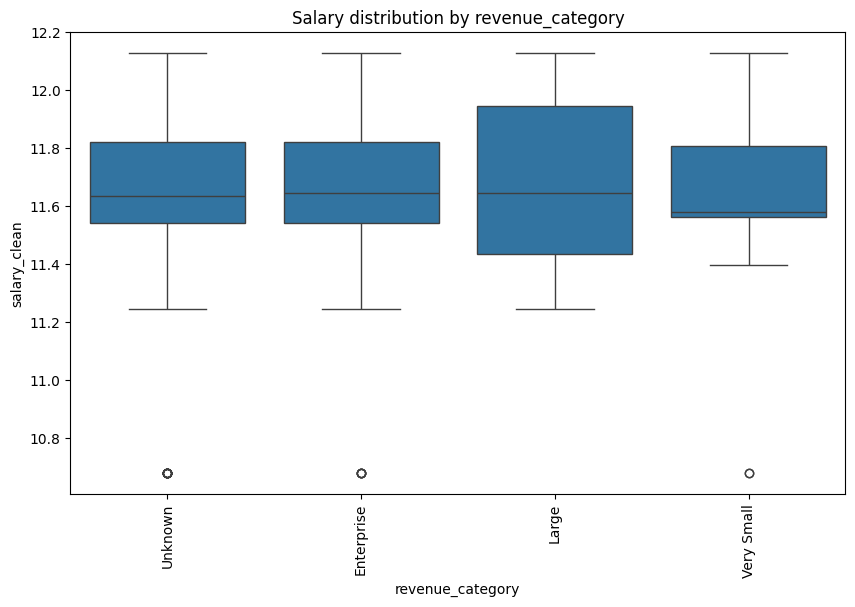

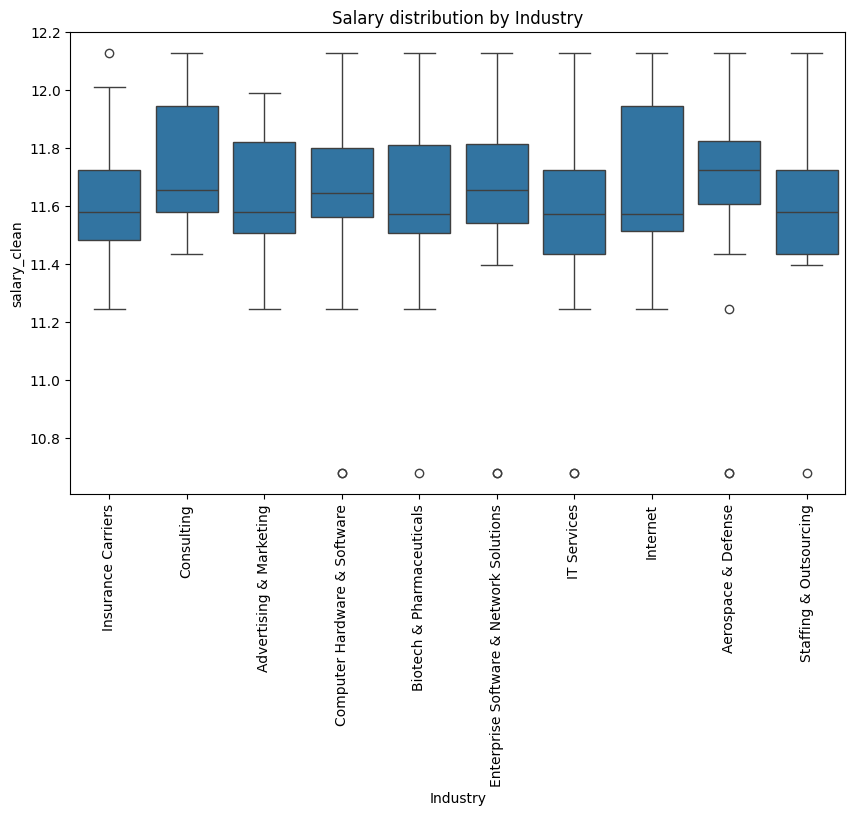

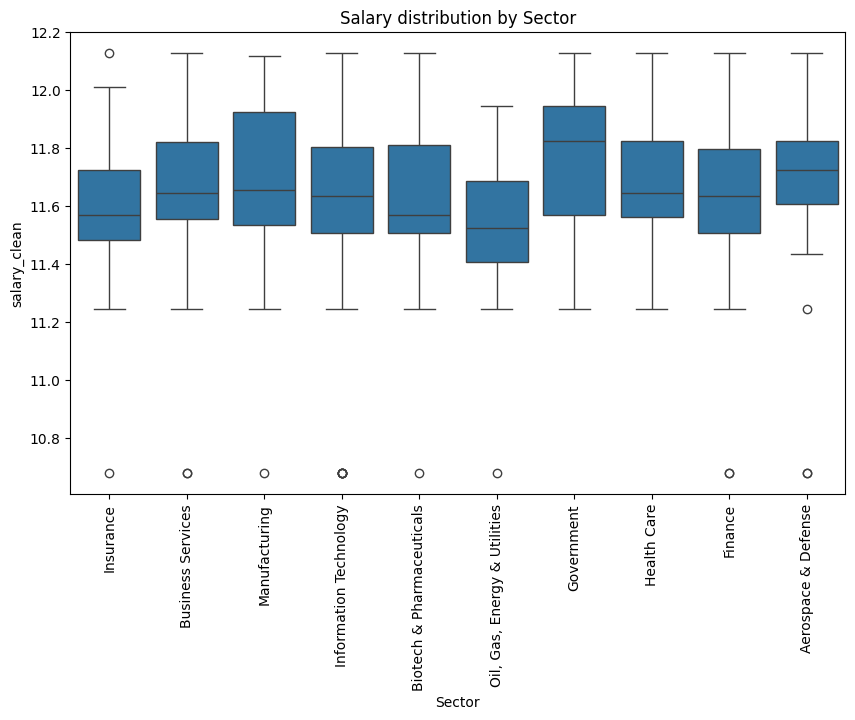

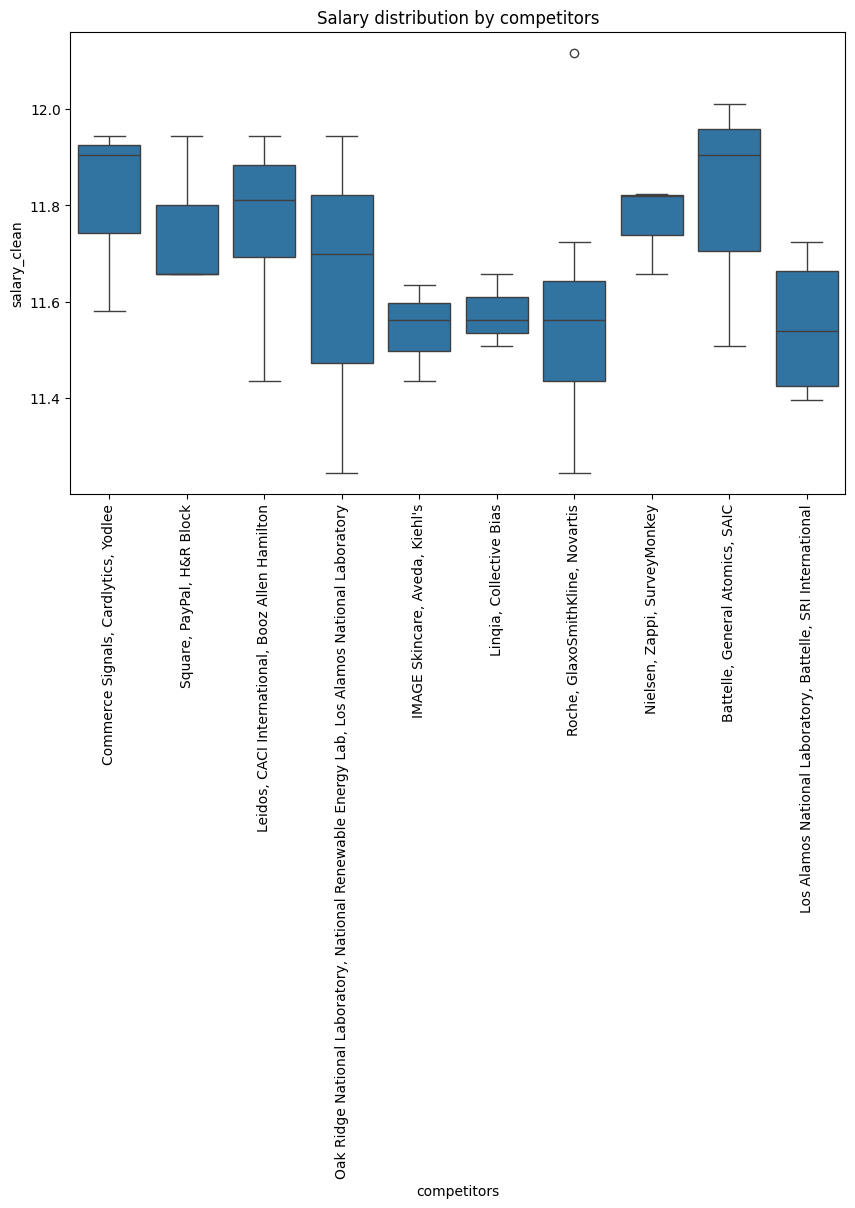

In [34]:

col_categorique = [
 'role',
 'company_name',
 'location',
 'size_category',
 'Headquarters',
 'ownership_category',
 'revenue_category', 
 'Industry',
 'Sector',
 'competitors'
 ]




import seaborn as sns
import matplotlib.pyplot as plt

for col in col_categorique:
    
    plt.figure(figsize=(10,6))
    
    # # garder seulement les 10 catégories les plus fréquentes
    top_values = df_cleaned[col].value_counts().nlargest(10).index
    df_top = df_cleaned[df_cleaned[col].isin(top_values)]
    
    sns.boxplot(
        x=col,
        y='salary_clean',
        data=df_top
    )
    
    plt.xticks(rotation=90)
    plt.title(f"Salary distribution by {col}")
    plt.show()


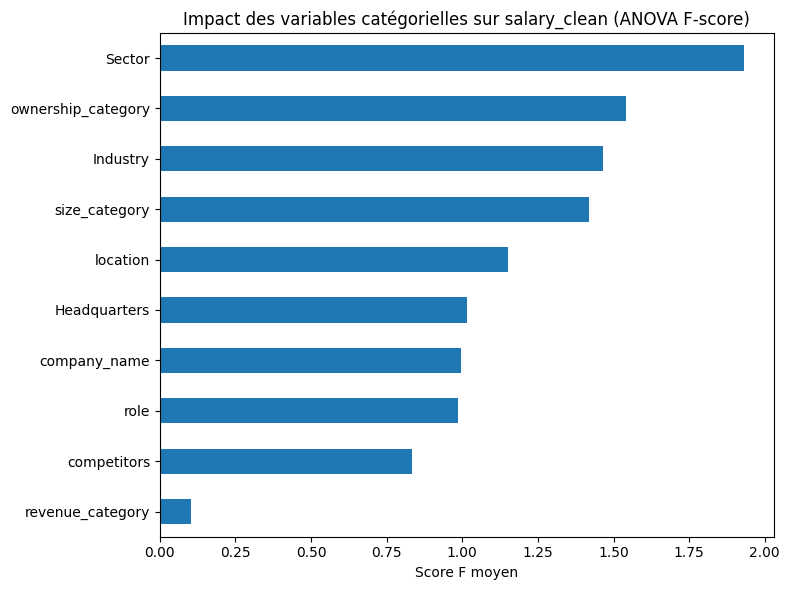

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression


col_categorique = [col for col in col_categorique if col in df_cleaned.columns]



X = pd.get_dummies(df_cleaned[col_categorique], drop_first=True)
y = df_cleaned["salary_clean"]



f_values, _ = f_regression(X, y)

feature_scores = pd.Series(f_values, index=X.columns)



group_scores = {}

for col in col_categorique:
    related_cols = [c for c in feature_scores.index if c.startswith(col + "_")]
    if related_cols:
        group_scores[col] = feature_scores[related_cols].mean()

group_scores = pd.Series(group_scores).sort_values()


plt.figure(figsize=(8,6))
group_scores.plot(kind="barh")
plt.title("Impact des variables catégorielles sur salary_clean (ANOVA F-score)")
plt.xlabel("Score F moyen")
plt.tight_layout()
plt.show()

## training data

In [36]:
df_clean = df_cleaned.drop(columns=['founded', 'Rating', 'company_name',  'size_category', 'revenue_category', 'Headquarters', 'competitors'])

In [37]:
col_cat = [
    'ownership_category',
    'Sector',
    'role',
    'Industry',
    'location'
]

In [38]:
df_clean

,role,salary_clean,Job Description,location,ownership_category,Industry,Sector
0,Data Scientist,11.944714,Description\n\nThe Senior Data Scientist is re...,NY,Nonprofit,Insurance Carriers,Insurance
1,Data Scientist,11.944714,"Secure our Nation, Ignite your Future\n\nJoin ...",VA,Public,Research & Development,Business Services
2,Data Scientist,11.944714,Overview\n\n\nAnalysis Group is one of the lar...,MA,Private,Consulting,Business Services
3,Data Scientist,11.944714,JOB DESCRIPTION:\n\nDo you have a passion for ...,MA,Public,Electrical & Electronic Manufacturing,Manufacturing
4,Data Scientist,11.944714,Data Scientist\nAffinity Solutions / Marketing...,NY,Private,Advertising & Marketing,Business Services
...,...,...,...,...,...,...,...
667,Data Scientist,11.820418,Summary\n\nWe’re looking for a data scientist ...,NJ,Private,Advertising & Marketing,Business Services
668,Data Scientist,11.820418,Job Description\nBecome a thought leader withi...,CA,Unknown,NaN,NaN
669,Data Scientist,11.820418,Join a thriving company that is changing the w...,CA,Unknown,NaN,NaN
670,Data Scientist,11.820418,100 Remote Opportunity As an AINLP Data Scient...,CA,Private,Advertising & Marketing,Business Services


In [39]:
# null values
df_clean.isnull().sum()

role                   0
salary_clean           0
Job Description        0
location               0
ownership_category     0
Industry              68
Sector                68
dtype: int64

In [40]:
df_clean = df_clean.dropna(subset=["Industry", "Sector"])

In [41]:
df_clean.isnull().sum()

role                  0
salary_clean          0
Job Description       0
location              0
ownership_category    0
Industry              0
Sector                0
dtype: int64

In [42]:
df_clean.dtypes

role                      str
salary_clean          float64
Job Description           str
location                  str
ownership_category        str
Industry                  str
Sector                    str
dtype: object

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)

embedding_reduced = pca.fit_transform(embeddings)

emb_df = pd.DataFrame(
    embedding_reduced,
    columns=[f"emb_{i}" for i in range(30)]
)


df_clean = df_cleaned.reset_index(drop=True)
emb_df = emb_df.reset_index(drop=True)

df_clean = pd.concat([df_clean, emb_df], axis=1)

df_clean = df_clean.drop(columns=["Job Description"])

embedding_columns = emb_df.columns.tolist()

col_num = embedding_columns

## Outliers

In [ ]:
def remove_salary_outliers(df, column="salary_clean", k=1.5):

# calcul des quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

# calcul de l’ecart interquartile
    IQR = Q3 - Q1

# determination des bornes
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    df_filtered = df[
        (df[column] >= lower) &
        (df[column] <= upper)
    ]

    return df_filtered


df_clean = remove_salary_outliers(df_clean, "salary_clean")

## Modelisation

In [45]:
from train import split_data, pipeline, metric_model
from sklearn.ensemble import RandomForestRegressor


In [46]:
x_train, x_test, y_train, y_test = split_data(df_clean, target="salary_clean")

In [47]:
model = pipeline(
    categorical_cols=col_cat,
    model=RandomForestRegressor(
        n_estimators=500,
        max_depth=25,
        random_state=42,
    ),
     k_best=5
)
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [48]:
y_pred = model.predict(x_test)

r2, mae, mse = metric_model(y_test, y_pred)


print("r2_score", r2)
print("mae", mae)
print("mse", mse)

r2_score -0.02694049970797696
mae 0.1814847540693726
mse 0.04878272654053005


In [49]:
# sauvgarde du model

import joblib

joblib.dump(model, 'training_models/predict_model.pkl')

['training_models/predict_model.pkl']